# Data Analyzing

Analyzing the interest in the Eco-Points campaign and behavior regarding Carbon Footprint (CFP) labels, segmented by Membership Status and demographics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the file
df = pd.read_csv('cleaned_response.csv')
cols_of_interest = ['motivated_by_eco_points', 'notice_cfp_label', 'feeling_on_digital_receipt']

### 1. M-Card Members Analysis

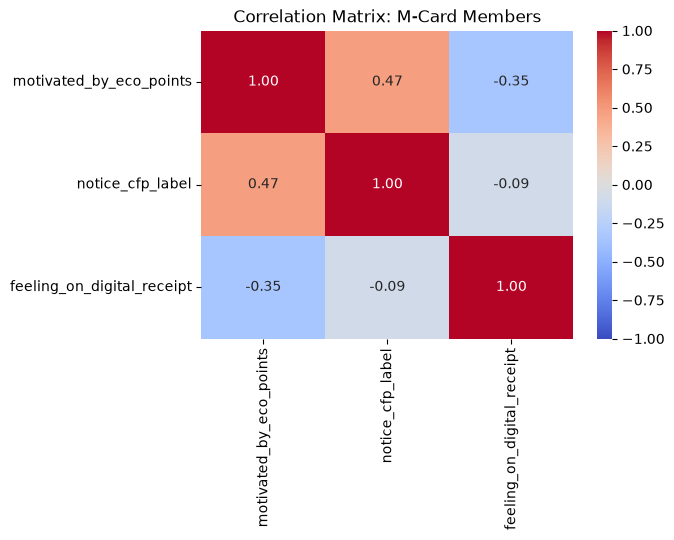

In [2]:
members_df = df[df['membership_status'] == 1]
corr_members = members_df[cols_of_interest].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_members, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: M-Card Members')
plt.show()

### 2. Non-Members Analysis

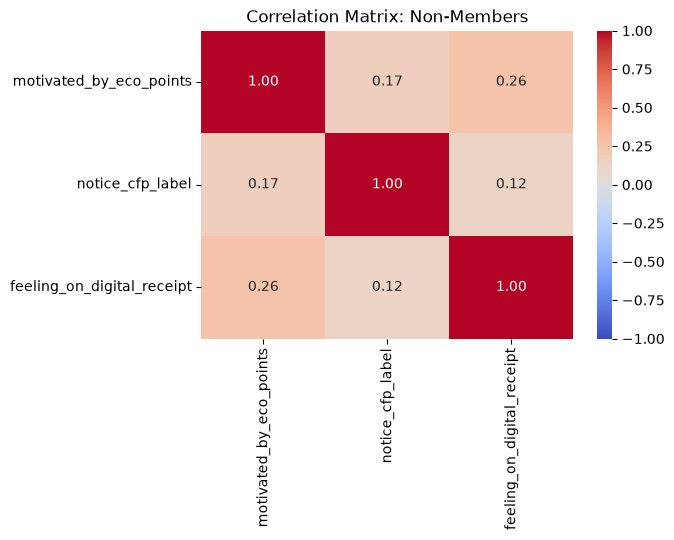

In [3]:
non_members_df = df[df['membership_status'] == 0]
corr_non_members = non_members_df[cols_of_interest].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_non_members, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Non-Members')
plt.show()

### 3. Overall Analysis (Both Groups)

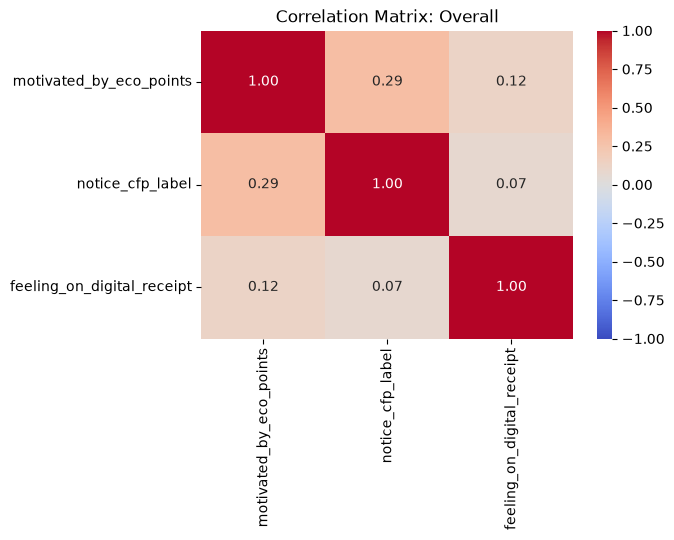

In [4]:
corr_overall = df[cols_of_interest].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_overall, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Overall')
plt.show()

### 4. Preferred Eco-Benefits Analysis

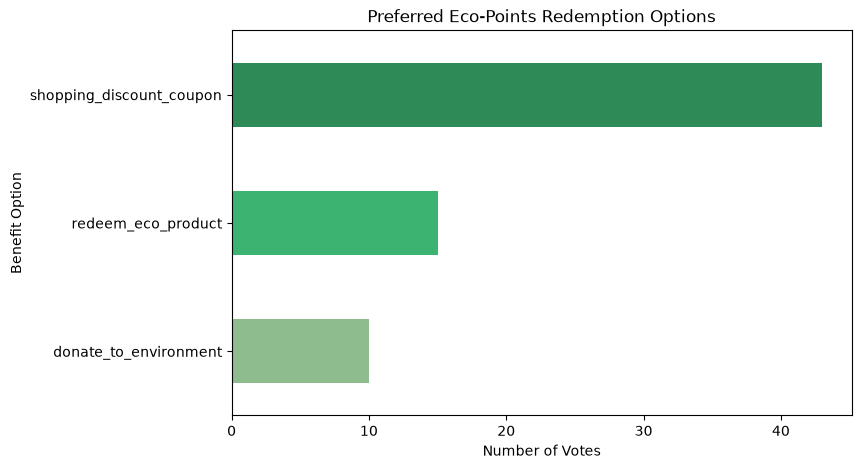

In [5]:
# Summing up the preferences
benefits_counts = df[['donate_to_environment', 'shopping_discount_coupon', 'redeem_eco_product']].sum()

plt.figure(figsize=(8, 5))
benefits_counts.sort_values().plot(kind='barh', color=['#8fbc8f', '#3cb371', '#2e8b57'])
plt.title('Preferred Eco-Points Redemption Options')
plt.xlabel('Number of Votes')
plt.ylabel('Benefit Option')
plt.show()

### 5. Target Demographic (Age Group)

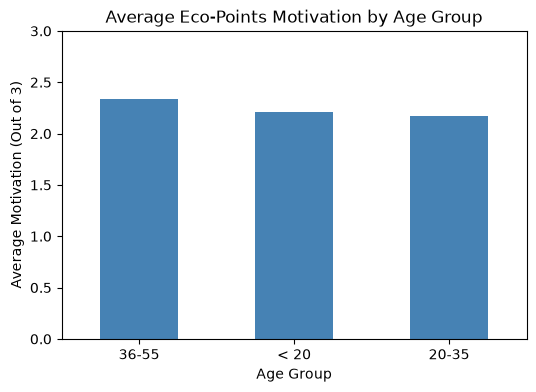

Number of respondents per age group:
age_group
20-35    35
< 20     14
36-55     3
Name: count, dtype: int64


In [6]:
# Grouping by age and finding average motivation
age_motivation = df.groupby('age_group')['motivated_by_eco_points'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
age_motivation.plot(kind='bar', color='#4682b4')
plt.title('Average Eco-Points Motivation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Motivation (Out of 3)')
plt.ylim(0, 3)
plt.xticks(rotation=0)
plt.show()

# Counting respondent distribution
print("Number of respondents per age group:")
print(df['age_group'].value_counts())